In [4]:
# Restart and reload modules
import importlib
import sys

# Add project path
sys.path.insert(0, '/Users/admin/Desktop/personal_projects/Madrid Open Data/madrid-open-data')

# Import modules
from rampa.duckdb.connection import get_duckdb_connection
from rampa.query.query_tools import Data_Collection

# Reload modules to get latest changes
importlib.reload(sys.modules['rampa.query.query_tools'])
importlib.reload(sys.modules['rampa.duckdb.connection'])

with open('../rampa/data/urls.json', 'r') as f:
    import json
    your_urls = json.load(f)

print(f"Found {len(your_urls)} URLs to process")
print(f"Available layer names: {list(your_urls.keys())}")

# Initialize with database connection
db_con = get_duckdb_connection("madrid_layers")
data_collection = Data_Collection(
    url_dict=your_urls, 
    db_connection=db_con
)

print("Data collection initialized successfully")

# Download all layers and store them
print("Starting download and storage process...")
data_collection.download_data(store_in_db=True)

# Load previously stored layers
data_collection.load_all_from_db()

# Get info about a stored layer - use the first available layer name
if your_urls:
    first_layer_name = list(your_urls.keys())[0]
    print(f"Getting info for layer: {first_layer_name}")
    info = data_collection.get_layer_info(first_layer_name)
    print(f"Layer info: {info}")
else:
    print("No layers available")

Found 1 URLs to process
Available layer names: ['AREAS_ACTIVIDADES_PARA_MAYORES']
Data collection initialized successfully
Starting download and storage process...


Loading layer AREAS_ACTIVIDADES_PARA_MAYORES from database...
Loaded 1 layers from database.
Getting info for layer: AREAS_ACTIVIDADES_PARA_MAYORES
Layer info: {'name': 'AREAS_ACTIVIDADES_PARA_MAYORES', 'source': 'https://sigma.madrid.es/hosted/rest/services/GEOPORTAL/AREAS_ACTIVIDADES_PARA_MAYORES/MapServer/0', 'record_count': 305, 'columns': ['ESRI_OID', 'DESC_CLASIFICACION', 'TIPO', 'ESTADO', 'FECHA_INSTALACION', 'TOTAL_ELEM', 'TIPO_VIA', 'NOM_VIA', 'NUM_VIA', 'NDP', 'DIRECCION_AUX', 'COD_POSTAL', 'BARRIO', 'DISTRITO', 'OBJECTID', 'SHAPE'], 'bounds': [432658.5580000002, 4465815.140000001, 453345.9790000003, 4487233.382999999], 'crs': 'EPSG:25830'}


<Axes: >

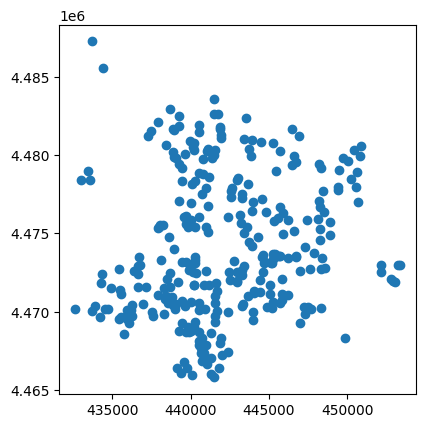

In [5]:
data_collection.data['AREAS_ACTIVIDADES_PARA_MAYORES'].plot()